# Function 2 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2)` that **maximizes** an unknown
("black-box") 2D function. A Gaussian Process (GP) surrogate model is fit to the observed
data, and acquisition functions (Upper Confidence Bound, Expected Improvement) are used to
decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_2/data/initial_inputs.npy")
y = np.load("function_2/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.818181, 0.929292],
    [0.575757, 0.999999],
    [0.666666, 0.262626],
    [0.828282, 0.151515],
    [0.545454, 0.131313],
    [0.707070, 0.888888],
    [0.666666, 0.028697],
    [0.686868, 0.909090],
    [0.000099, 0.999999],
    [0.300000, 0.600000],
    [0.999999, 0.000001],
    [0.696969, 0.898993],
    [0.707070, 0.925925],
    ], axis=0)

y = np.append(y, [
    0.1577835350800182,
    0.08084127857059048,
    0.41612989805060224,
    0.01933160976262964,
    0.06378290447377503,
    0.6084935885370348,
    0.5300360144442293,
    0.5662818395833944,
    -0.004460250776989616,
    0.029043072875958233,
    -0.13920362028296135,
    0.5987380481966609,
    0.600417852848383,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (23, 2), y shape: (23,)
Best observed y so far: 0.6112052157614438


## 3. Exploratory Visualization

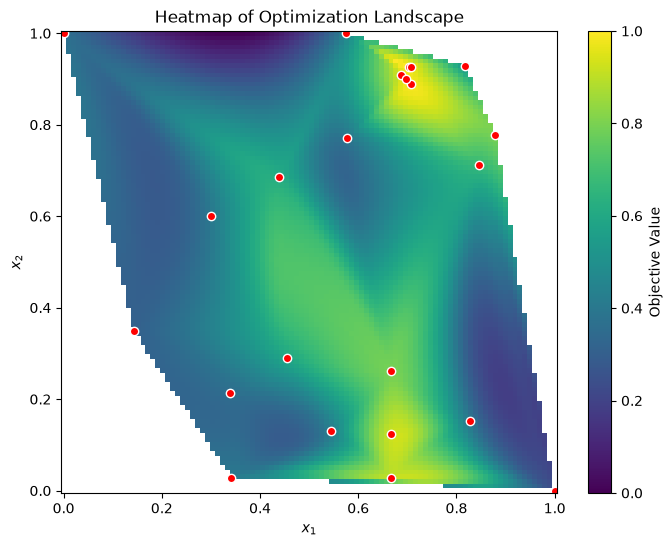

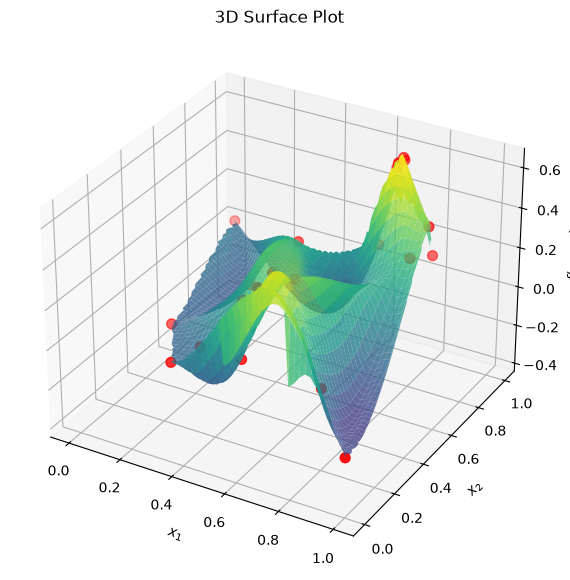

In [4]:
x_axis = X[:, 0]
y_axis = X[:, 1]

xi = np.linspace(x_axis.min(), x_axis.max(), 100)
yi = np.linspace(y_axis.min(), y_axis.max(), 100)
XI, YI = np.meshgrid(xi, yi)
ZI = griddata((x_axis, y_axis), y, (XI, YI), method='cubic')

plt.figure(figsize=(8, 6))
plt.pcolormesh(XI, YI, ZI, shading='auto', cmap='viridis')
plt.scatter(x_axis, y_axis, c='red', edgecolors='white', label='Sample Points')
plt.colorbar(label='Objective Value')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Heatmap of Optimization Landscape')
plt.savefig("function_2/function_2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.8)
ax.scatter(x_axis, y_axis, y, color='red', s=50)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
plt.title('3D Surface Plot')
plt.savefig("function_2/function_2_3d_surface_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Gaussian Process Surrogate Model

In [5]:
noise_assumption = 1e-1

kernel = C(1.0) * Matern(length_scale=0.1, length_scale_bounds=(0.01, 1.0), nu=1.5)

gp_model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
gp_model.fit(X, y)

x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(0, 1, 100)
x_grid, y_grid = np.meshgrid(x_coords, y_coords)
X_test = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

mean, std = gp_model.predict(X_test, return_std=True)

## 5. Acquisition Functions

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off.

In [6]:
kappa = 10.0
ucb = mean + kappa * std
next_idx = np.argmax(ucb)
next_point = X_test[next_idx]

print(f"Suggested Next Iteration Point (UCB): {next_point}")

Suggested Next Iteration Point (UCB): [0. 0.]


### Expected Improvement (EI)
`xi` is the exploration parameter.

In [7]:
def expected_improvement(X, model, current_best, xi=0.001):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    mask = sigma > 0
    ei = np.zeros_like(mu)

    improvement = mu[mask] - current_best - xi
    z = improvement / sigma[mask]

    ei[mask] = (improvement * norm.cdf(z) +
                sigma[mask] * norm.pdf(z))

    return ei

current_best_y = np.max(y)
ei_values = expected_improvement(X_test, gp_model, current_best_y)
next_idx = np.argmax(ei_values)
next_point = X_test[next_idx]
print(f"Suggested Next Iteration Point (EI): {next_point}")

Suggested Next Iteration Point (EI): [1. 1.]


Third iteration: `kappa` lowered from 5 to 0.5 and the kernel length-scale from 0.1 to 0.05,
to investigate whether there is a connected ridge between the two peaks seen in the plots above.

## 6. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, indices `[0, 1, 9, 12]`) or
"negative", and a small neural network is trained on that split as a sanity check on whether
the acquisition function's suggested `next_point` also looks promising from a classification
standpoint. This is exploratory and not part of the core GP/acquisition-function decision loop.

In [8]:
y_labels = np.zeros(len(X))
positive_indices = [0, 1, 9, 12]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0000
 1    | 2.7396
 2    | 0.0000
 3    | 2.7052
 4    | 0.1378
 5    | 0.3674
 6    | 0.0075
 7    | 0.0187
 8    | 0.0055
 9    | 1.4661
10    | 2.1816
11    | 0.0878
12    | 6.3565
13    | 2.5064
14    | 4.7645
15    | 1.6842
16    | 0.9089
17    | 4.0526
18    | 0.0000
19    | 0.0002
20    | 0.0000
21    | 5.3204
22    | 1.4964


In [9]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.4446
Predicted Class: 0


## 7. Results Summary

Observed yield over the most recent iterations:

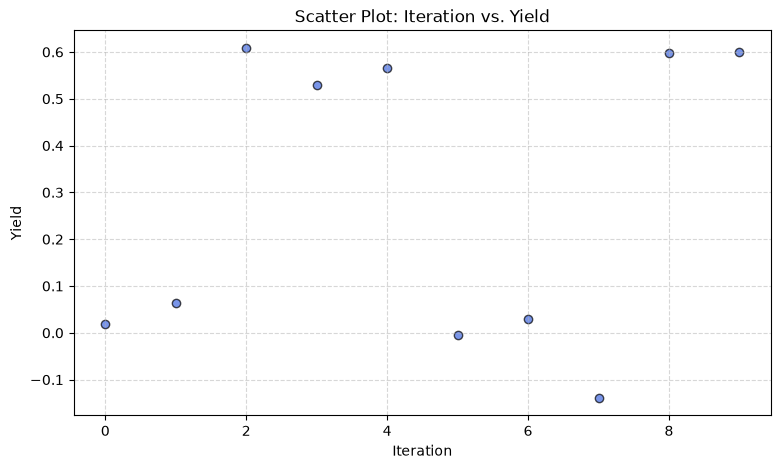

In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()